# Direct Marketing Campaign Response & ROI Optimization

# 1. Load Libraries and Raw Data

In [4]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style='whitegrid')

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score
)
from sklearn.ensemble import RandomForestClassifier


In [ ]:
PROJECT_ROOT = Path.cwd()
RAW_DATA_PATH = PROJECT_ROOT / 'data' / 'bank-full.csv'

df_raw = pd.read_csv(RAW_DATA_PATH, sep=';')
df_raw.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no


# 2. Initial Data Quality Checks

In [6]:
print(f'Rows: {df_raw.shape[0]:,}')
print(f'Columns: {df_raw.shape[1]:,}')

column_profile = pd.DataFrame({
    'column': df_raw.columns,
    'dtype': [df_raw[col].dtype for col in df_raw.columns],
    'non_null_count': [df_raw[col].notna().sum() for col in df_raw.columns],
    'missing_count': [df_raw[col].isna().sum() for col in df_raw.columns],
    'missing_rate': [df_raw[col].isna().mean() for col in df_raw.columns],
    'unique_values': [df_raw[col].nunique(dropna=False) for col in df_raw.columns]
})

column_profile

Rows: 45,211
Columns: 17


,column,dtype,non_null_count,missing_count,missing_rate,unique_values
0,age,int64,45211,0,0.0,77
1,job,str,45211,0,0.0,12
2,marital,str,45211,0,0.0,3
3,education,str,45211,0,0.0,4
4,default,str,45211,0,0.0,2
5,balance,int64,45211,0,0.0,7168
6,housing,str,45211,0,0.0,2
7,loan,str,45211,0,0.0,2
8,contact,str,45211,0,0.0,3
9,day,int64,45211,0,0.0,31


Before creating features, we check shape, column metadata, missing values, duplicate rows, target distribution, etc. to confirm whether the file is ready for further analysis.
The raw dataset contains 45,211 customer contact records and 17 columns. The file contains no null and missing data.

In [7]:
duplicate_rows = df_raw.duplicated().sum()
print(f'Duplicate rows: {duplicate_rows:,}')

target_summary = (
    df_raw['y']
    .value_counts(dropna=False)
    .rename_axis('y')
    .reset_index(name='customers_count')
)
target_summary['pcustomers_percentage'] = round(target_summary['customers_count'] * 100.0 / len(df_raw), 2)
target_summary

Duplicate rows: 0


,y,customers_count,pcustomers_percentage
0,no,39922,88.3
1,yes,5289,11.7


The target feature distribution shows the campaign response baseline - Most contacted customers did not subscribe (88.3%)

In [8]:
categorical_columns = df_raw.select_dtypes(include=['object', 'str']).columns.tolist()

unknown_summary = []
for col in categorical_columns:
    unknown_count = df_raw[col].eq('unknown').sum()
    unknown_summary.append({
        'column': col,
        'unknown_count': unknown_count,
        'unknown_percentage': round(unknown_count * 100.0 / len(df_raw), 2)
    })

pd.DataFrame(unknown_summary).sort_values('unknown_percentage', ascending=False)

,column,unknown_count,unknown_percentage
8,poutcome,36959,81.75
6,contact,13020,28.80
2,education,1857,4.11
0,job,288,0.64
1,marital,0,0.00
3,default,0,0.00
5,loan,0,0.00
4,housing,0,0.00
7,month,0,0.00
9,y,0,0.00


Some categorical fields use **unknown** as a filler rather than an actual null value. These values should be preserved for now because **unknown** may carry business meaning, especially for `contact` feature or `poutcome` (previous campaign outcome).

In [9]:
numeric_columns = df_raw.select_dtypes(include='number').columns.tolist()
df_raw[numeric_columns].describe().T

,count,mean,std,min,25%,50%,75%,max
age,45211.0,40.936210,10.618762,18.0,33.0,39.0,48.0,95.0
balance,45211.0,1362.272058,3044.765829,-8019.0,72.0,448.0,1428.0,102127.0
day,45211.0,15.806419,8.322476,1.0,8.0,16.0,21.0,31.0
duration,45211.0,258.163080,257.527812,0.0,103.0,180.0,319.0,4918.0
campaign,45211.0,2.763841,3.098021,1.0,1.0,2.0,3.0,63.0
pdays,45211.0,40.197828,100.128746,-1.0,-1.0,-1.0,-1.0,871.0
previous,45211.0,0.580323,2.303441,0.0,0.0,0.0,0.0,275.0


This summary gives the range and distribution of numeric features such as customer age, balance, campaign contacts, previous contacts, and related campaign timing fields. These distributions will guide the segmentation groups created later in the project.

# 3. Feature Engineering

## (1) Create Target Variable and Business KPI Variables

The original outcome feature is `y`, where `yes` means the customer subscribed to the bank term deposit and `no` means they did not.

Target definition:

```text
response_flag = 1 if y == "yes"
response_flag = 0 if y == "no"
```

The original dataset does not include features such as campaign cost or product profitability, so for this project, we will some synthetic assumptions to translate response outcomes into business metrics.

#### **Business Assumptions**:
- Each customer contact attempt costs **$2**.
- Each successful term deposit subscription creates **$100** in expected profit.

Because the raw field `campaign` counts the number of contacts performed for the customer during this campaign, row-level historical contact cost is calculated as:

```text
estimated_contact_cost = campaign * contact_cost_per_attempt
```

Please note these assumptions are not actual bank financials. They are included for targeting decisions to be evaluated using cost per response, estimated profit, and ROI.

In [10]:
CONTACT_COST_PER_ATTEMPT = 2.00
EXPECTED_PROFIT_PER_RESPONSE = 100.00

df = df_raw.copy()

df['contact_cost_per_attempt'] = CONTACT_COST_PER_ATTEMPT
df['expected_profit_per_response'] = EXPECTED_PROFIT_PER_RESPONSE

df['customer_id'] = np.arange(1, len(df) + 1)
df['contacted_customer'] = 1
df['contact_attempts'] = df['campaign']

df['response_flag'] = np.where(df['y'].eq('yes'), 1, 0)
df['response_count'] = df['response_flag']

df['estimated_response_value'] = df['response_flag'] * df['expected_profit_per_response']
df['estimated_contact_cost'] = df['campaign'] * df['contact_cost_per_attempt']
df['estimated_gross_profit'] = df['response_flag'] * df['expected_profit_per_response']
df['estimated_net_profit'] = df['estimated_gross_profit'] - df['estimated_contact_cost']

df.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,...,expected_profit_per_response,customer_id,contacted_customer,contact_attempts,response_flag,response_count,estimated_response_value,estimated_contact_cost,estimated_gross_profit,estimated_net_profit
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,...,100.0,1,1,1,0,0,0.0,2.0,0.0,-2.0
1,44,technician,single,secondary,no,29,yes,no,unknown,5,...,100.0,2,1,1,0,0,0.0,2.0,0.0,-2.0
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,...,100.0,3,1,1,0,0,0.0,2.0,0.0,-2.0
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,...,100.0,4,1,1,0,0,0.0,2.0,0.0,-2.0
4,33,unknown,single,unknown,no,1,no,no,unknown,5,...,100.0,5,1,1,0,0,0.0,2.0,0.0,-2.0


## (2) Create Segmentation Variables

Segmentation variables should also help to understand the dataset in a more business-oriented perspective, rather than as simple raw numeric features.

In [11]:
month_order = ['jan', 'feb', 'mar', 'apr', 'may', 'jun', 'jul', 'aug', 'sep', 'oct', 'nov', 'dec']

df['age_group'] = pd.cut(
    df['age'],
    bins=[17, 29, 39, 49, 59, 69, 120],
    labels=['18-29', '30-39', '40-49', '50-59', '60-69', '70+']
)

df['balance_group'] = pd.cut(
    df['balance'],
    bins=[-np.inf, -1, 0, 999, 4999, np.inf],
    labels=['negative', 'zero', '1-999', '1,000-4,999', '5,000+']
)

df['campaign_contact_group'] = pd.cut(
    df['campaign'],
    bins=[0, 1, 2, 3, 5, np.inf],
    labels=['1', '2', '3', '4-5', '6+']
)

df['previous_contact_flag'] = np.where(df['previous'].gt(0), 'previously_contacted', 'not_previously_contacted')
df['previous_contact_group'] = pd.cut(
    df['previous'],
    bins=[-1, 0, 1, 3, np.inf],
    labels=['0', '1', '2-3', '4+']
)

df['pdays_status'] = np.where(df['pdays'].eq(-1), 'not_previously_contacted', 'previously_contacted')
df['loan_profile'] = np.select(
    [
        df['housing'].eq('yes') & df['loan'].eq('yes'),
        df['housing'].eq('yes') & df['loan'].eq('no'),
        df['housing'].eq('no') & df['loan'].eq('yes'),
        df['housing'].eq('no') & df['loan'].eq('no')
    ],
    [
        'housing_and_personal_loan',
        'housing_loan_only',
        'personal_loan_only',
        'no_housing_or_personal_loan'
    ],
    default='unknown'
)

df['month'] = pd.Categorical(df['month'], categories=month_order, ordered=True)

segment_columns = [
    'age_group',
    'balance_group',
    'campaign_contact_group',
    'previous_contact_flag',
    'previous_contact_group',
    'pdays_status',
    'loan_profile'
]

df[segment_columns].head()

,age_group,balance_group,campaign_contact_group,previous_contact_flag,previous_contact_group,pdays_status,loan_profile
0,50-59,"1,000-4,999",1,not_previously_contacted,0,not_previously_contacted,housing_loan_only
1,40-49,1-999,1,not_previously_contacted,0,not_previously_contacted,housing_loan_only
2,30-39,1-999,1,not_previously_contacted,0,not_previously_contacted,housing_and_personal_loan
3,40-49,"1,000-4,999",1,not_previously_contacted,0,not_previously_contacted,housing_loan_only
4,30-39,1-999,1,not_previously_contacted,0,not_previously_contacted,no_housing_or_personal_loan


## (3) Exclude `duration` From the Clean Modeling Dataset

In this dataset, `duration` measures the length of the customer contact in seconds. It is highly predictive of the response because a customer who stays on a call longer is more likely to subscribe.

However, this field is not available before deciding whom to contact. If we used `duration` to build a targeting model, we would be using information that only exists after the campaign interaction has already happened. That would create target leakage and make the model look unrealistically strong.

Therefore, we will:
- Keep `duration` in the untouched raw dataset.
- Exclude `duration` from the analysis/modeling dataset.

In [12]:
leakage_columns = ['duration']

df_clean = df.drop(columns=leakage_columns).copy()

print('duration in raw dataset:', 'duration' in df_raw.columns)
print('duration in clean dataset:', 'duration' in df_clean.columns)

duration in raw dataset: True
duration in clean dataset: False


# 4. Exploratory Data Analysis (EDA)

## (1) Helper Functions

* `build_kpi_summary`: Run performance analysis on business KPI metrics
* `plot_factor_metric`: Create barplots for business KPI metrics

In [13]:
def build_kpi_summary(data, group_cols=None, sort_by='response_rate', ascending=False):

    if group_cols is None:
        summary = pd.DataFrame({
            'contacted_customers': [data['contacted_customer'].sum()],
            'total_contact_attempts': [data['contact_attempts'].sum()],
            'responses': [data['response_count'].sum()],
            'estimated_contact_cost': [data['estimated_contact_cost'].sum()],
            'estimated_gross_profit': [data['estimated_gross_profit'].sum()],
            'estimated_net_profit': [data['estimated_net_profit'].sum()]
        })

        summary['response_rate'] = summary['responses'] / summary['contacted_customers']
        summary['contact_attempts_per_customer'] = summary['total_contact_attempts'] / summary['contacted_customers']
        summary['cost_per_response'] = np.where(
            summary['responses'].gt(0),
            summary['estimated_contact_cost'] / summary['responses'],
            np.nan
        )
        summary['roi'] = summary['estimated_net_profit'] / summary['estimated_contact_cost']

        metric_cols = [
                'contacted_customers',
                'total_contact_attempts',
                'contact_attempts_per_customer', 
                'responses',
                'response_rate',
                'estimated_gross_profit',
                'estimated_contact_cost',
                'estimated_net_profit',
                'cost_per_response',
                'roi'
            ]

        return summary[metric_cols]
    
    else:

        group_kpi_tables = []

        for group in group_cols:
            summary = (
                data.groupby(group, dropna=False, observed=True)
                .agg(
                    contacted_customers=('contacted_customer', 'sum'),
                    total_contact_attempts=('contact_attempts', 'sum'),
                    responses=('response_count', 'sum'),
                    estimated_contact_cost=('estimated_contact_cost', 'sum'),
                    estimated_gross_profit=('estimated_gross_profit', 'sum'),
                    estimated_net_profit=('estimated_net_profit', 'sum')
                )
                .reset_index()
            )
            summary['group'] = group
            summary['segment'] = summary[group].astype(str)
            summary['response_rate'] = summary['responses'] / summary['contacted_customers']
            summary['contact_attempts_per_customer'] = summary['total_contact_attempts'] / summary['contacted_customers']
            summary['cost_per_response'] = np.where(
                summary['responses'].gt(0),
                summary['estimated_contact_cost'] / summary['responses'],
                np.nan
            )
            summary['roi'] = summary['estimated_net_profit'] / summary['estimated_contact_cost']
            
            group_kpi_tables.append(summary[[
                'group',
                'segment',
                'contacted_customers',
                'total_contact_attempts',
                'contact_attempts_per_customer',
                'responses',
                'response_rate',
                'estimated_gross_profit',
                'estimated_contact_cost',
                'estimated_net_profit',
                'cost_per_response',
                'roi'
            ]])
        
        summary = pd.concat(group_kpi_tables, ignore_index=True)
        
        if sort_by is not None:
            summary = summary.sort_values(by = sort_by, ascending = ascending)

        return summary


In [14]:
def plot_factor_metric(data, group, metric, title, top_n = None):

    plot_data = data[data['group'].eq(group)].copy()
    plot_data = plot_data.sort_values(metric, ascending=False)

    if top_n is not None:
        plot_data = plot_data.head(top_n)
        plot_data = plot_data.sort_values(metric, ascending=True)

    fig_height = max(4, 0.25 * len(plot_data) + 1.5) #adjusted to be dynamic
    fig, ax = plt.subplots(figsize=(10, fig_height))
    sns.barplot(data=plot_data, x=metric, y='segment', ax=ax)

    ax.set_title(title, fontsize=14, weight='bold', pad=12)
    ax.set_xlabel(metric.replace('_', ' ').title())
    ax.set_ylabel('')
    ax.grid(axis='x', alpha=0.25)
    ax.grid(axis='y', visible=False)

    if metric in ['response_rate', 'roi']:
        ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda value, _: f'{value:.0%}'))
        labels = [f'{value:.1%}' for value in plot_data[metric]]
    elif metric in ['estimated_net_profit', 'estimated_contact_cost', 'estimated_gross_profit']:
        ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda value, _: f'${value/1000:,.0f}K'))
        labels = [f'${value/1000:,.0f}K' for value in plot_data[metric]]
    else:
        labels = [f'{value:,.1f}' for value in plot_data[metric]]

    x_max = plot_data[metric].max()
    label_offset = x_max * 0.02

    for patch, label, customers in zip(ax.patches, labels, plot_data['contacted_customers']):
        width = patch.get_width()
        y = patch.get_y() + patch.get_height() / 2
        ax.text(width + label_offset, y, f'{label} | n={customers:,.0f}', va='center', fontsize=9)

    ax.set_xlim(right=x_max * 1.5)
    sns.despine(left=True, bottom=True)
    plt.tight_layout()
    plt.show()

## (2) Overall Metrics

In [112]:
overall_kpis = build_kpi_summary(df_clean)
overall_kpis

,contacted_customers,total_contact_attempts,contact_attempts_per_customer,responses,response_rate,estimated_gross_profit,estimated_contact_cost,estimated_net_profit,cost_per_response,roi
0,45211,124956,2.7638,5289,0.1170,"528,900.0000","249,912.0000","278,988.0000",47.2513,1.1163


The overall campaign reached 45,211 customers, generated 5,289 responses, which is about 11.7% response rate. Under the project assumptions, the historical campaign is profitable overall with $278,988 net profit and 1.12 ROI, but the average may hide major differences across different groups. We will review some groups in detail below.

## (3) Campaign Features

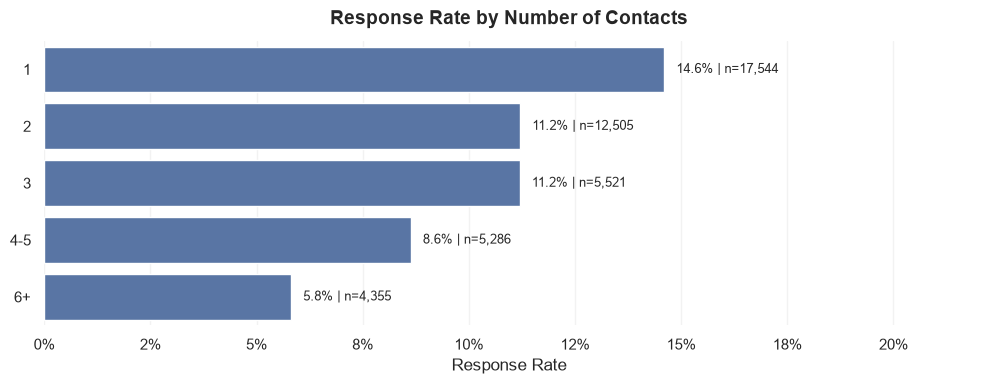

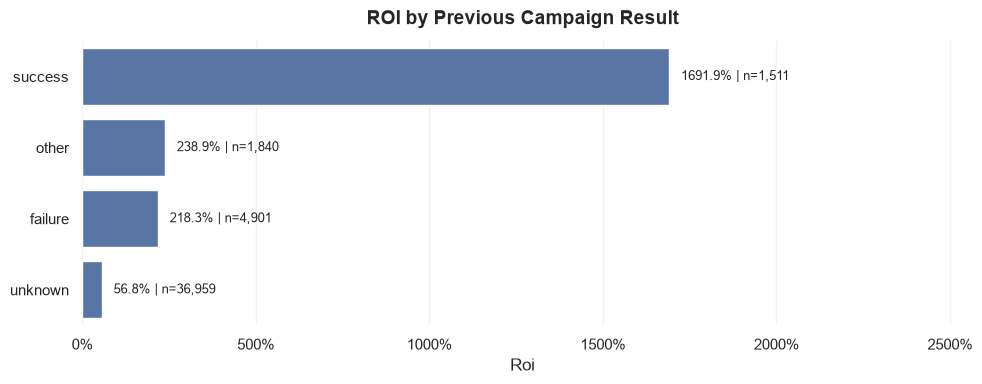

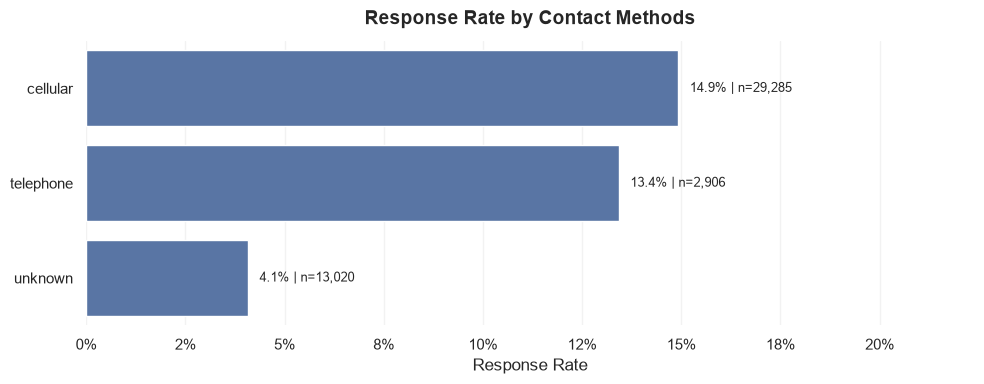

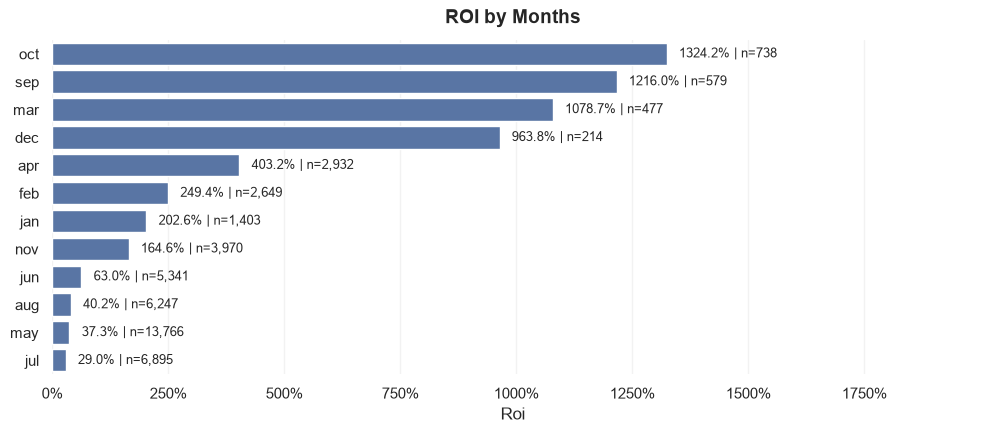

In [15]:
campaign_features = ['campaign_contact_group', 'poutcome', 'contact', 'month']
campaign_kpis = build_kpi_summary(df_clean, campaign_features)

plot_factor_metric(campaign_kpis, 'campaign_contact_group', 'response_rate', 'Response Rate by Number of Contacts')
plot_factor_metric(campaign_kpis, 'poutcome', 'roi', 'ROI by Previous Campaign Result')
plot_factor_metric(campaign_kpis, 'contact', 'response_rate', 'Response Rate by Contact Methods')
plot_factor_metric(campaign_kpis, 'month', 'roi', 'ROI by Months')

* Customers contacted once (`1`) have the highest response rate among contact-count groups. Performance declines as contact attempts increase, and the `6+` contact group has the weakest response rate under the current assumptions.
* Customers with a previous campaign `success` show by far the highest ROI at **1691.9%**, making them the strongest-performing segment despite a relatively small sample size. Customers with `unknown` previous results have the lowest ROI at **56.8%**, even though they make up the largest group.
* `Cellular` contact has the strongest ROI among contact channels. The `unknown` contact channel performs poorly and has negative estimated ROI, making it an important field to investigate before modeling.
* ROI varies heavily by month, with `October`, `September`, `March`, and `December` producing exceptionally high returns above **900%**. In contrast, high-volume months like `May`, `July`, and `August` have much lower ROI, suggesting campaign timing may matter more than contact volume.

## (4) Demographic Features

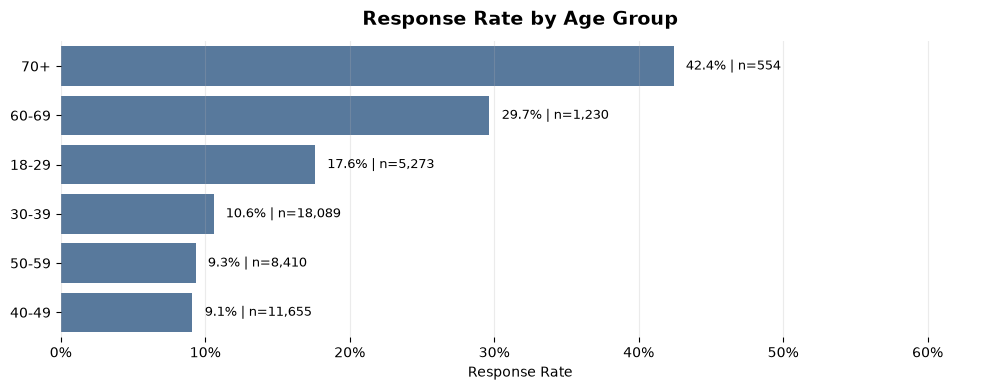

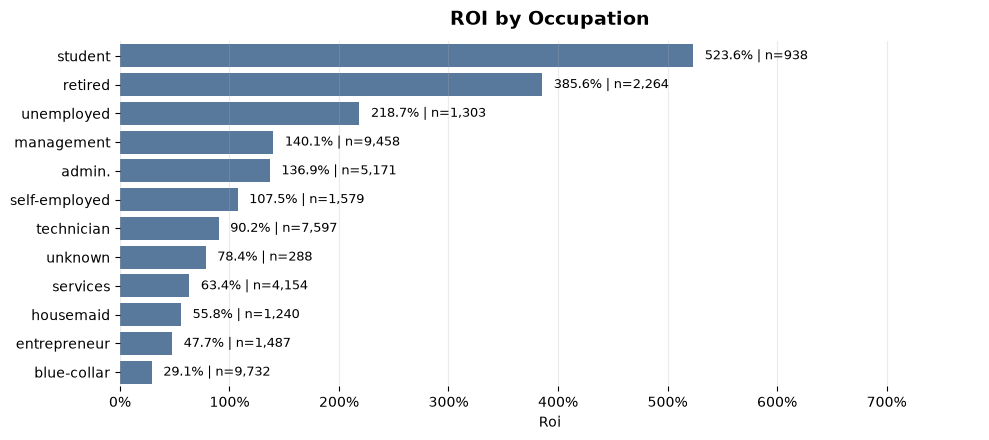

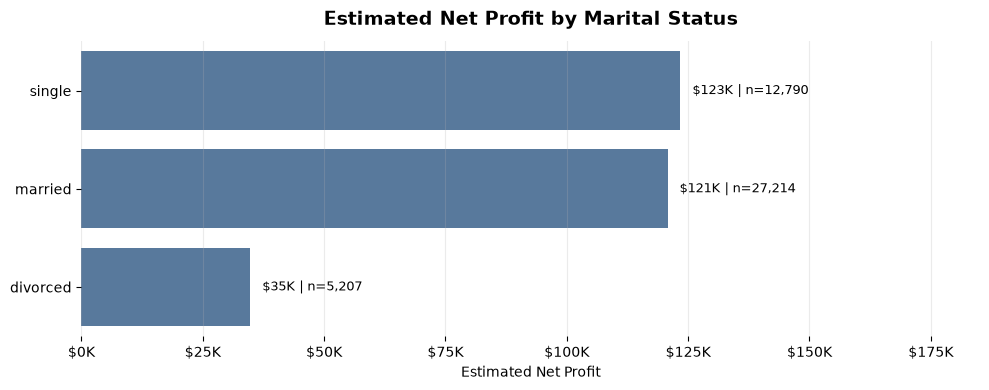

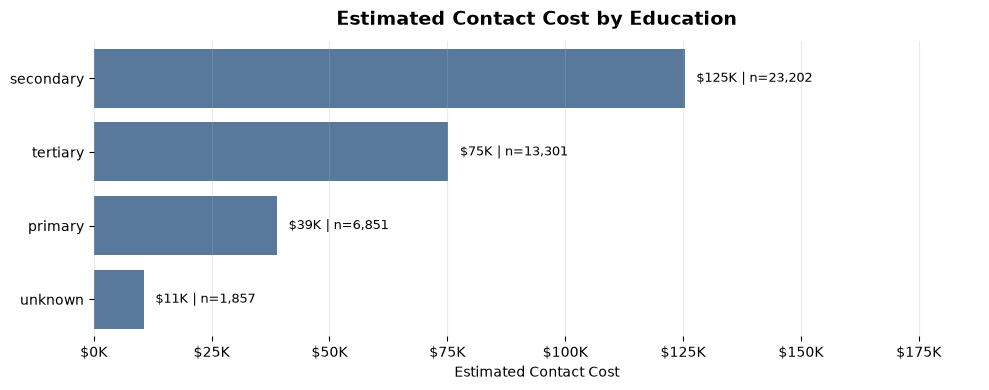

In [197]:
demographic_features = ['age_group', 'job', 'marital', 'education']
demographic_kpis = build_kpi_summary(df_clean, demographic_features)

plot_factor_metric(demographic_kpis, 'age_group', 'response_rate', 'Response Rate by Age Group')
plot_factor_metric(demographic_kpis, 'job', 'roi', 'ROI by Occupation')
plot_factor_metric(demographic_kpis, 'marital', 'estimated_net_profit', 'Estimated Net Profit by Marital Status')
plot_factor_metric(demographic_kpis, 'education', 'estimated_contact_cost', 'Estimated Contact Cost by Education')

* Response rates are highest among older customers, especially the `70+` group at **42.4%** and `60-69` group at **29.7%**. Middle-aged groups have much lower response rates, with `40-49` and `50-59` both around **9%**, despite having much larger sample sizes.
* ROI varies sharply by occupation: `students` and `retired` customers deliver the highest returns at **523.6%** and **385.6%**, far above all other groups. `Blue-collar` customers have the lowest ROI at **29.1%** despite having the largest sample size, suggesting high volume does not necessarily translate into profitability.
* `Single` and `married` customers generate nearly the same estimated net profit, at about **$123K** and **$121K** respectively. `Divorced` customers contribute much less at **$35K**, partly reflecting their smaller sample size.
* Contact costs are highest for customers with `secondary` education, at about **$125K**, driven by the largest contacted group size. `Tertiary` and `primary` groups cost less at about **$75K** and **$39K**, while the `unknown` education group has the lowest cost at **$11K**.

## (5) Financial Features

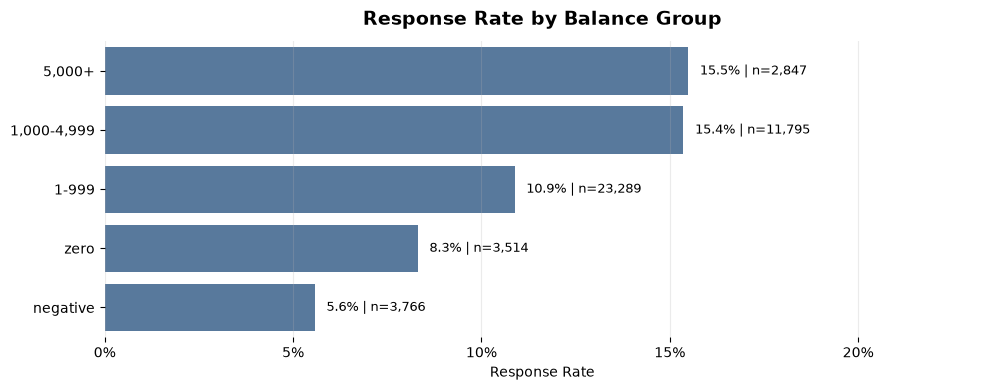

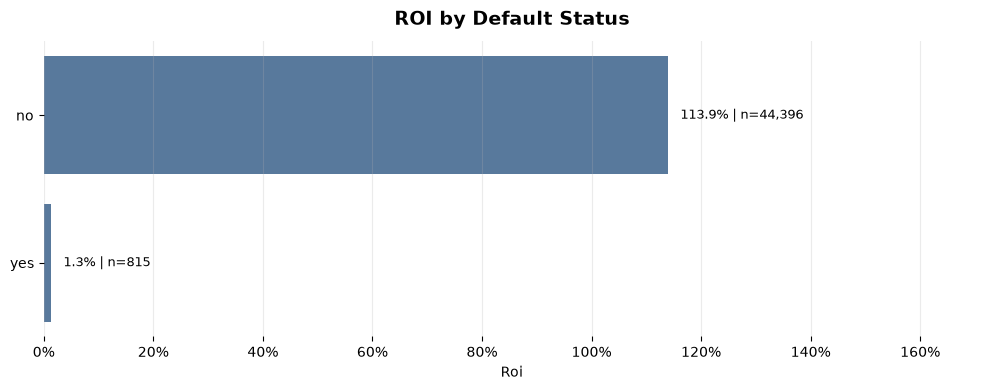

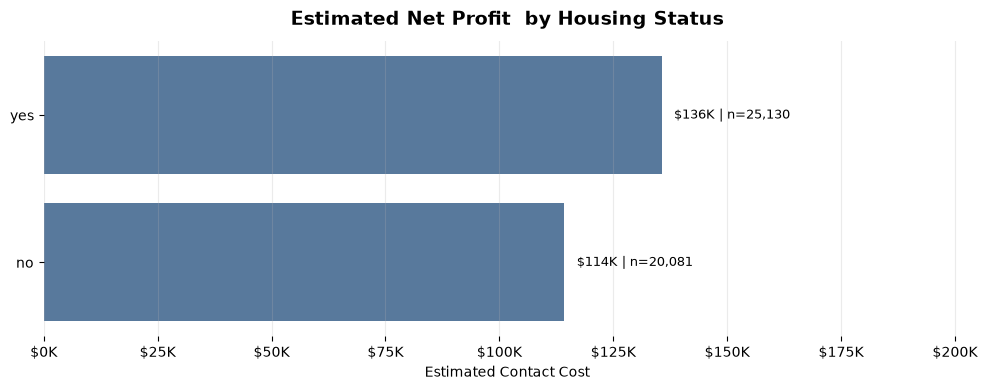

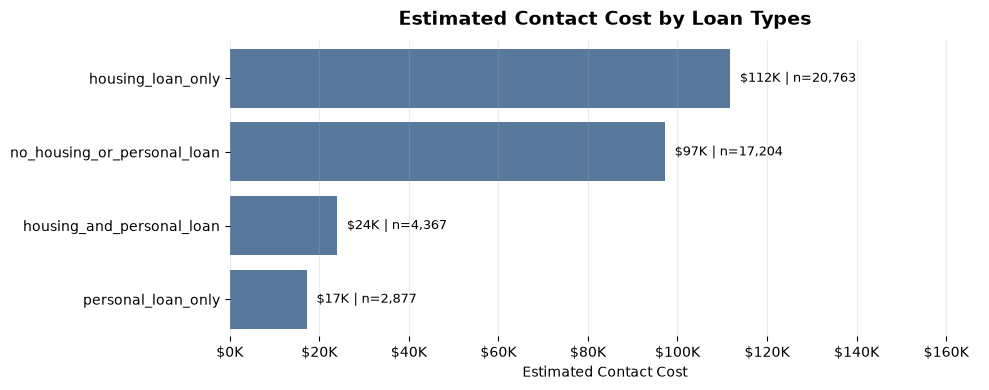

In [198]:
financial_features = ['balance_group', 'default', 'housing', 'loan_profile']
financial_kpis = build_kpi_summary(df_clean, financial_features)

plot_factor_metric(financial_kpis, 'balance_group', 'response_rate', 'Response Rate by Balance Group')
plot_factor_metric(financial_kpis, 'default', 'roi', 'ROI by Default Status')
plot_factor_metric(financial_kpis, 'housing', 'estimated_contact_cost', 'Estimated Net Profit  by Housing Status')
plot_factor_metric(financial_kpis, 'loan_profile', 'estimated_contact_cost', 'Estimated Contact Cost by Loan Types')

* Response rate generally rises with account balance: customers with balances of `1,000+` respond at about **15.4-15.5%**, while `negative`-balance customers respond at only **5.6%**. This suggests higher-balance customers are more receptive to the campaign.
* `Customers without default` have much stronger ROI at **113.9%**, while `customers in default` are almost flat at **1.3%**. This suggests default status is a major profitability risk signal.
* `Customers with housing loans` generate slightly higher estimated net profit, about **$136K**, compared with **$114K** for those `without housing loans`. The difference is partly supported by the larger customer count in the housing-loan group.
* Contact cost is highest for the `housing_loan_only` group at about **$112K**, followed by customers with `no housing` or `personal loan` at **$97K**. Groups involving personal loans are much smaller and have much lower total contact costs.

## (6) Strongest and Weakest Features

Setting a minimum feature size of 100 contacted customers to keep the results from being driven by small features.

In [205]:
minimum_feature_size = 100

all_features = campaign_features + demographic_features + financial_features
all_kpis = build_kpi_summary(df_clean, all_features)

eligible_features = all_kpis[
    all_kpis['contacted_customers'].ge(minimum_feature_size)
].copy()

highest_response_features = eligible_features.sort_values('response_rate', ascending=False).head(10)
weakest_response_features = eligible_features.sort_values('response_rate', ascending=True).head(10)
most_profitable_features = eligible_features.sort_values('estimated_net_profit', ascending=False).head(10)
highest_roi_features = eligible_features.sort_values('roi', ascending=False).head(10)

highest_response_features[[
    'group',
    'segment',
    'contacted_customers',
    'responses',
    'response_rate',
    'roi',
    'estimated_net_profit'
]]

,group,segment,contacted_customers,responses,response_rate,roi,estimated_net_profit
7,poutcome,success,1511,978,0.6473,16.9187,"92,342.0000"
14,month,mar,477,248,0.5199,10.7871,"22,696.0000"
23,month,dec,214,100,0.4673,9.6383,"9,060.0000"
20,month,sep,579,269,0.4646,12.1605,"24,856.0000"
21,month,oct,738,323,0.4377,13.2416,"30,032.0000"
29,age_group,70+,554,235,0.4242,9.1644,"21,188.0000"
28,age_group,60-69,1230,365,0.2967,5.1676,"30,582.0000"
38,job,student,938,269,0.2868,5.2355,"22,586.0000"
35,job,retired,2264,516,0.2279,3.8560,"40,974.0000"
15,month,apr,2932,577,0.1968,4.0323,"46,234.0000"


The highest response-rate features include previous outcome with success group, months with March, December, September, and October, and customers age 60+. These groups should be watched closely during modeling because they show strong raw response behavior.

In [207]:
weakest_response_features[[
    'group',
    'segment',
    'contacted_customers',
    'responses',
    'response_rate',
    'roi',
    'estimated_net_profit'
]]

,group,segment,contacted_customers,responses,response_rate,roi,estimated_net_profit
11,contact,unknown,13020,530,0.0407,-0.2698,"-19,586.0000"
49,balance_group,negative,3766,210,0.0558,-0.0474,"-1,044.0000"
4,campaign_contact_group,6+,4355,253,0.0581,-0.7053,"-60,562.0000"
58,loan_profile,housing_and_personal_loan,4367,265,0.0607,0.1079,"2,580.0000"
55,default,yes,815,52,0.0638,0.0133,68.0000
16,month,may,13766,925,0.0672,0.3727,"25,114.0000"
31,job,blue-collar,9732,708,0.0727,0.2913,"15,970.0000"
61,loan_profile,personal_loan_only,2877,219,0.0761,0.2771,"4,752.0000"
57,housing,yes,25130,1935,0.0770,0.4267,"57,874.0000"
59,loan_profile,housing_loan_only,20763,1670,0.0804,0.4950,"55,294.0000"


The weakest response-rate segments include unknown-contact methods, negative-balance customers, customers who were contacted more than 6 times, customers with both housing and personal loans, and customers with credit default. These groups may need lower priority unless the model finds stronger interaction effects.

In [208]:
most_profitable_features[[
    'group',
    'segment',
    'contacted_customers',
    'responses',
    'response_rate',
    'roi',
    'estimated_net_profit'
]]

,group,segment,contacted_customers,responses,response_rate,roi,estimated_net_profit
9,contact,cellular,29285,4369,0.1492,1.7729,"279,340.0000"
54,default,no,44396,5237,0.1180,1.1395,"278,920.0000"
56,housing,no,20081,3354,0.1670,1.9347,"221,114.0000"
0,campaign_contact_group,1,17544,2561,0.1460,6.2988,"221,012.0000"
60,loan_profile,no_housing_or_personal_loan,17204,3135,0.1822,2.2274,"216,362.0000"
51,balance_group,1-999,23289,2534,0.1088,0.9706,"124,808.0000"
47,education,tertiary,13301,1996,0.1501,1.6555,"124,434.0000"
44,marital,single,12790,1912,0.1495,1.8208,"123,418.0000"
8,poutcome,unknown,36959,3386,0.0916,0.5677,"122,620.0000"
43,marital,married,27214,2755,0.1012,0.7805,"120,768.0000"


The most profitable segments by estimated net profit are not always the highest response-rate groups. Large segments such as customers contacted through cellular, customers with no default, no housing or personal loan, and mid-to-high balances generate the largest total profit because they combine meaningful volume with solid response rates.

# 5. Modeling

The objective of modeling is to predict `response_flag`, where `1` means the customer subscribed to the term deposit and `0` means the customer did not subscribe.

## (1) Final Dataset Prep

### (a) Feature Selection

The business wants to know which customers are most likely to respond before initiating campaigns. Therefore, the feature set must only include information that would be available before or at the time of campaign targeting.

Excluded fields:
- `duration`: call duration is only known after the customer is contacted, so it creates target leakage.
- `y`: original response label.
- `response_flag`: target variable, not a feature.
- `estimated_gross_profit`, `estimated_net_profit`, `estimated_response_value`: directly depend on the response.
- `customer_id`, `contacted_customer`, `response_count`: Reporting-only fields

The selected feature set keeps customer profile, financial profile, timing/contact, and previous campaign history fields that can support pre-contact targeting.

In [211]:
modeling_data = df_clean.copy()

target_column = 'response_flag'

numeric_features = [
    'age',
    'balance',
    'day',
    'campaign',
    'pdays',
    'previous'
]

categorical_features = [
    'job',
    'marital',
    'education',
    'default',
    'housing',
    'loan',
    'contact',
    'month',
    'poutcome',
    'age_group',
    'balance_group',
    'campaign_contact_group',
    'previous_contact_flag',
    'previous_contact_group',
    'pdays_status',
    'loan_profile'
]

modeling_features = numeric_features + categorical_features

X = modeling_data[modeling_features].copy()
y = modeling_data[target_column].copy()

print(f'Modeling rows: {len(X):,}')
print(f'Modeling features: {len(modeling_features):,}')
print(f'Numeric features: {len(numeric_features):,}')
print(f'Categorical features: {len(categorical_features):,}')
print(f'Target response rate: {y.mean():.2%}')

Modeling rows: 45,211
Modeling features: 22
Numeric features: 6
Categorical features: 16
Target response rate: 11.70%


### (b) Train/Test Split

Because only about 11.7% of customers responded, the target is imbalanced. A basic random split could create train and test sets with slightly different response rates, which would make evaluation less reliable. Therefore, we will use stratified split because it preserves the response/non-response ratio in both sets. The test set is held out for model evaluation in later sections.

In [214]:
RANDOM_STATE = 42
TEST_SIZE = 0.20

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size = TEST_SIZE,
    random_state = RANDOM_STATE,
    stratify = y
)

split_summary = pd.DataFrame({
    'dataset': ['full', 'train', 'test'],
    'rows': [len(y), len(y_train), len(y_test)],
    'responses': [y.sum(), y_train.sum(), y_test.sum()],
    'response_rate': [y.mean(), y_train.mean(), y_test.mean()]
})

split_summary

,dataset,rows,responses,response_rate
0,full,45211,5289,0.1170
1,train,36168,4231,0.1170
2,test,9043,1058,0.1170


### (c) Preprocessing Pipeline

The model will receive a mix of numeric and categorical fields. Before proceeding with modeling, categorical variables need to be encoded and numeric variables should be examined.

- Numeric fields: impute missing values with the median, then scale values for models that are sensitive to feature magnitude.
- Categorical fields: impute missing values with the most frequent value, then one-hot encode categories.

Even though we checked thoroughly on the missing data / nulls in earlier steps, we will keep imputers in the pipeline to make the workflow more robust and production-like.

In [219]:
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('numeric', numeric_transformer, numeric_features),
        ('categorical', categorical_transformer, categorical_features)
    ]
)

X_train_prepared = preprocessor.fit_transform(X_train)
X_test_prepared = preprocessor.transform(X_test)

print(f'Prepared train shape: {X_train_prepared.shape}')
print(f'Prepared test shape: {X_test_prepared.shape}')

Prepared train shape: (36168, 78)
Prepared test shape: (9043, 78)


## (2) Baseline Model - Logistic Regression

We chose logistic regression as the base model because it provides a simple yet interpretable benchmark for predicting customer response before comparing against more complex models. The goal is not only to classify customers as responders or non-responders, but to rank customers by response likelihood for business to prioritize the highest-scoring customers.

### (a) Model Training

Because responders are the minority class, the model uses `class_weight='balanced'`. This informs logistic regression to give more weight to the responder class during training instead of optimizing for the non-responder class.

In [221]:
baseline_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', LogisticRegression(
        max_iter=1000,
        class_weight='balanced',
        solver='liblinear',
        random_state = RANDOM_STATE
    ))
])

baseline_model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](22,)","['age','balance','day',...,'previous_contact_group','pdays_status', 'loan_profile']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,22
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('numeric', ...), ('categorical', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remaind

### (b) Model Evaluation

- ROC AUC measures how well the model separates responders from non-responders across thresholds.
- Average precision / PR AUC is useful for imbalanced datasets because it focuses more directly on positive-class ranking quality.
- Accuracy is not critical in evaluation as a model could achieve high accuracy by predicting non-response too often

In [223]:
y_test_pred = baseline_model.predict(X_test)
y_test_proba = baseline_model.predict_proba(X_test)[:, 1]

baseline_metrics = pd.DataFrame([{
    'accuracy': accuracy_score(y_test, y_test_pred),
    'precision': precision_score(y_test, y_test_pred, zero_division=0),
    'recall': recall_score(y_test, y_test_pred, zero_division=0),
    'f1_score': f1_score(y_test, y_test_pred, zero_division=0),
    'roc_auc': roc_auc_score(y_test, y_test_proba),
    'average_precision_pr_auc': average_precision_score(y_test, y_test_proba),
    'baseline_response_rate': y_test.mean()
}])

baseline_metrics

,accuracy,precision,recall,f1_score,roc_auc,average_precision_pr_auc,baseline_response_rate
0,0.7655,0.2803,0.6408,0.3900,0.7784,0.4139,0.1170


The baseline model reaches about 76.5% accuracy, 28.0% precision, 64.1% recall, 39.0% F1, 77.8% ROC AUC, and 41.4% PR AUC. Accuracy alone understates the tradeoff: the model is intentionally more willing to flag likely responders, which improves recall but lowers precision.

In [225]:
confusion = confusion_matrix(y_test, y_test_pred)
confusion_matrix_df = pd.DataFrame(
    confusion,
    index=['actual_no_response', 'actual_response'],
    columns=['predicted_no_response', 'predicted_response']
)

confusion_matrix_df

,predicted_no_response,predicted_response
actual_no_response,6244,1741
actual_response,380,678


The confusion matrix shows the class-balance tradeoff clearly. The model correctly finds many responders, but it also flags a meaningful number of non-responders as likely responders.

### (c) Ranking Evaluation

A good targeting model should assign higher scores to actual responders than to non-responders, then concentrate responses in the top score groups.

In [224]:
baseline_predictions = pd.DataFrame({
    'actual_response_flag': y_test.values,
    'predicted_response_flag': y_test_pred,
    'predicted_response_probability': y_test_proba
}, index=y_test.index).reset_index(names='row_id')

baseline_predictions['actual_label'] = np.where(
    baseline_predictions['actual_response_flag'].eq(1),
    'response',
    'no_response'
)

score_by_actual = (
    baseline_predictions.groupby('actual_label')
    .agg(
        customers=('actual_response_flag', 'count'),
        avg_predicted_probability=('predicted_response_probability', 'mean'),
        median_predicted_probability=('predicted_response_probability', 'median')
    )
    .reset_index()
)

score_by_actual

,actual_label,customers,avg_predicted_probability,median_predicted_probability
0,no_response,7985,0.3810,0.3647
1,response,1058,0.6174,0.6102


Actual responders receive a much higher average predicted probability than non-responders. This is the first sign that the baseline model is useful for ranking customers, not just assigning class labels.

### (d) Tile Lift Analysis

Tile analysis turns model scores into a business targeting view. The test set is sorted by predicted response probability and divided into 10 equally sized groups, such that tile 1 contains the highest-scoring customers.

Lift compares each tile's response rate against the overall test response rate. For example, lift of `4.0` means that group responds at four times the average test-set response rate.

In [226]:
baseline_response_rate = baseline_predictions['actual_response_flag'].mean()
total_test_responses = baseline_predictions['actual_response_flag'].sum()

baseline_predictions['score_Tile'] = pd.qcut(
    baseline_predictions['predicted_response_probability'].rank(method='first'),
    q=10,
    labels=range(10, 0, -1)
)

baseline_Tile_lift = (
    baseline_predictions.groupby('score_Tile', observed=True)
    .agg(
        customers=('actual_response_flag', 'count'),
        responses=('actual_response_flag', 'sum'),
        avg_predicted_probability=('predicted_response_probability', 'mean'),
        min_predicted_probability=('predicted_response_probability', 'min'),
        max_predicted_probability=('predicted_response_probability', 'max')
    )
    .reset_index()
)
baseline_Tile_lift['score_Tile'] = baseline_Tile_lift['score_Tile'].astype(int)
baseline_Tile_lift = baseline_Tile_lift.sort_values('score_Tile')

baseline_Tile_lift['response_rate'] = baseline_Tile_lift['responses'] / baseline_Tile_lift['customers']
baseline_Tile_lift['lift'] = baseline_Tile_lift['response_rate'] / baseline_response_rate
baseline_Tile_lift['cumulative_customers'] = baseline_Tile_lift['customers'].cumsum()
baseline_Tile_lift['cumulative_responses'] = baseline_Tile_lift['responses'].cumsum()
baseline_Tile_lift['cumulative_response_rate'] = baseline_Tile_lift['cumulative_responses'] / baseline_Tile_lift['cumulative_customers']
baseline_Tile_lift['cumulative_lift'] = baseline_Tile_lift['cumulative_response_rate'] / baseline_response_rate
baseline_Tile_lift['share_of_total_responses_captured'] = baseline_Tile_lift['cumulative_responses'] / total_test_responses

baseline_Tile_lift

,score_Tile,customers,responses,avg_predicted_probability,min_predicted_probability,max_predicted_probability,response_rate,lift,cumulative_customers,cumulative_responses,cumulative_response_rate,cumulative_lift,share_of_total_responses_captured
9,1,905,439,0.8374,0.6824,0.9939,0.4851,4.1461,905,439,0.4851,4.1461,0.4149
8,2,904,162,0.6027,0.5484,0.6824,0.1792,1.5317,1809,601,0.3322,2.8396,0.5681
7,3,904,108,0.5116,0.4820,0.5481,0.1195,1.0211,2713,709,0.2613,2.2337,0.6701
6,4,904,80,0.4536,0.4277,0.4819,0.0885,0.7564,3617,789,0.2181,1.8645,0.7457
5,5,904,68,0.4048,0.3824,0.4277,0.0752,0.6429,4521,857,0.1896,1.6202,0.8100
4,6,905,58,0.3603,0.3377,0.3823,0.0641,0.5478,5426,915,0.1686,1.4413,0.8648
3,7,904,50,0.3135,0.2892,0.3376,0.0553,0.4727,6330,965,0.1524,1.3030,0.9121
2,8,904,37,0.2624,0.2325,0.2892,0.0409,0.3498,7234,1002,0.1385,1.1839,0.9471
1,9,904,29,0.2022,0.1726,0.2325,0.0321,0.2742,8138,1031,0.1267,1.0828,0.9745
0,10,905,27,0.1382,0.0130,0.1725,0.0298,0.2550,9043,1058,0.1170,1.0000,1.0000


The top score tile has about a 48.5% response rate, compared with the 11.7% test-set baseline. That is roughly 4.15x lift, which means the baseline model is already useful for prioritizing likely responders.

## (3) Test Model A: Random Forest

We will use random forest classifier as a test model to compare with baseline model. Random forests are useful for comparison here because they can capture nonlinear patterns and interactions between features without requiring those interactions to be manually specified.

For this project, the random forest model is evaluated through the same business lens as baseline model:

- Does it rank responders better?
- Does it improve top-tile lift?
- Does it capture more responders in the highest-scoring customer groups?

### (a) Model Training

The model also uses `class_weight='balanced_subsample'` to help with the 11.7% responder rate while fitting each tree.

In [228]:
rf_preprocessor = ColumnTransformer(
    transformers=[
        ('numeric', SimpleImputer(strategy='median'), numeric_features),
        ('categorical', Pipeline(steps=[
            ('imputer', SimpleImputer(strategy='most_frequent')),
            ('onehot', OneHotEncoder(handle_unknown='ignore'))
        ]), categorical_features)
    ]
)

full_rf_model = Pipeline(steps=[
    ('preprocessor', rf_preprocessor),
    ('model', RandomForestClassifier(
        n_estimators=300,
        min_samples_leaf=20,
        class_weight='balanced_subsample',
        random_state= RANDOM_STATE,
        n_jobs=-1
    ))
])

full_rf_model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](22,)","['age','balance','day',...,'previous_contact_group','pdays_status', 'loan_profile']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,22
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('numeric', ...), ('categorical', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remaind

### (b) Model Evaluation

In [229]:
full_rf_test_pred = full_rf_model.predict(X_test)
full_rf_test_proba = full_rf_model.predict_proba(X_test)[:, 1]

full_rf_metrics = pd.DataFrame([{
    'model': 'full_random_forest',
    'accuracy': accuracy_score(y_test, full_rf_test_pred),
    'precision': precision_score(y_test, full_rf_test_pred, zero_division=0),
    'recall': recall_score(y_test, full_rf_test_pred, zero_division=0),
    'f1_score': f1_score(y_test, full_rf_test_pred, zero_division=0),
    'roc_auc': roc_auc_score(y_test, full_rf_test_proba),
    'average_precision_pr_auc': average_precision_score(y_test, full_rf_test_proba),
    'baseline_response_rate': y_test.mean()
}])

full_rf_metrics

,model,accuracy,precision,recall,f1_score,roc_auc,average_precision_pr_auc,baseline_response_rate
0,full_random_forest,0.8255,0.3519,0.5841,0.4392,0.7933,0.4320,0.1170


Random forest model shows improvement over the baseline model on accuracy, precision, F1, ROC AUC, and PR AUC. Recall is lower than the baseline model, but random forest produces a better overall ranking signal for targeting.

In [230]:
full_rf_confusion_matrix = pd.DataFrame(
    confusion_matrix(y_test, full_rf_test_pred),
    index=['actual_no_response', 'actual_response'],
    columns=['predicted_no_response', 'predicted_response']
)

full_rf_confusion_matrix

,predicted_no_response,predicted_response
actual_no_response,6847,1138
actual_response,440,618


Random forest confusion matrix shows a different tradeoff from baseline model: it is more conservative about predicting response, which improves precision but reduces recall. However, the probability ranking is more important than the default 0.50 threshold in this project.

### (c) Feature Importance Review

Feature importance review should help identify which fields the model relies on most. Once finished reviewing, we will rerun the random forest model with the reduced-features with high importance features.

Because categorical variables are one-hot encoded, the first output is at the transformed-feature level, such as `month_mar` or `job_student`. For business interpretation, those one-hot importances are also rolled back up to the original fields. For example, all `job_*` dummy variables are aggregated into the original feature `job`.

In [231]:
fitted_preprocessor = full_rf_model.named_steps['preprocessor']
fitted_full_rf = full_rf_model.named_steps['model']

categorical_feature_names = (
    fitted_preprocessor
    .named_transformers_['categorical']
    .named_steps['onehot']
    .get_feature_names_out(categorical_features)
    .tolist()
)
transformed_feature_names = numeric_features + categorical_feature_names

full_rf_transformed_importance = pd.DataFrame({
    'transformed_feature': transformed_feature_names,
    'importance': fitted_full_rf.feature_importances_
})

original_feature_names = []
for transformed_feature in full_rf_transformed_importance['transformed_feature']:
    if transformed_feature in numeric_features:
        original_feature_names.append(transformed_feature)
    else:
        matched_feature = transformed_feature
        for col in categorical_features:
            if transformed_feature.startswith(f'{col}_'):
                matched_feature = col
                break
        original_feature_names.append(matched_feature)

full_rf_transformed_importance['original_feature'] = original_feature_names
full_rf_transformed_importance = full_rf_transformed_importance.sort_values('importance', ascending=False)

full_rf_original_importance = (
    full_rf_transformed_importance
    .groupby('original_feature', as_index=False)['importance']
    .sum()
    .sort_values('importance', ascending=False)
)
full_rf_original_importance['cumulative_importance'] = full_rf_original_importance['importance'].cumsum()

full_rf_original_importance

,original_feature,importance,cumulative_importance
14,month,0.1169,0.1169
6,contact,0.1037,0.2205
17,poutcome,0.0910,0.3116
12,loan,0.0783,0.3898
2,balance,0.0750,0.4648
0,age,0.0685,0.5333
7,day,0.0610,0.5942
10,housing,0.0492,0.6434
1,age_group,0.0402,0.6836
15,pdays,0.0401,0.7237


The highest-importance original fields are led by month, contact channel, prior campaign outcome, loan status, balance, age, day of month, and housing status. This aligns well with the earlier EDA, where campaign timing, channel quality, prior outcomes, and financial profile were strong signals.

## (4) Test Model B: Reduced-Feature Random Forest

More complex model is not automatically better for an analysis or a business stakeholder. After reviewing feature importance, we test whether a smaller feature set can preserve or improve targeting performance.

Feature selection rule:
- Keep original features in descending importance order.
- Include at least the top 10 original features.
- Continue adding features until cumulative importance reaches at least 95%.

### (a) Model Training

In [232]:
selected_high_importance_features = []
for _, row in full_rf_original_importance.iterrows():
    selected_high_importance_features.append(row['original_feature'])
    if len(selected_high_importance_features) >= 10 and row['cumulative_importance'] >= 0.95:
        break

reduced_numeric_features = [feature for feature in numeric_features if feature in selected_high_importance_features]
reduced_categorical_features = [feature for feature in categorical_features if feature in selected_high_importance_features]

pd.DataFrame({
    'selected_feature': selected_high_importance_features,
    'feature_type': [
        'numeric' if feature in reduced_numeric_features else 'categorical'
        for feature in selected_high_importance_features
    ]
})

,selected_feature,feature_type
0,month,categorical
1,contact,categorical
2,poutcome,categorical
3,loan,categorical
4,balance,numeric
5,age,numeric
6,day,numeric
7,housing,categorical
8,age_group,categorical
9,pdays,numeric


In [234]:
reduced_rf_preprocessor = ColumnTransformer(
    transformers=[
        ('numeric', SimpleImputer(strategy='median'), reduced_numeric_features),
        ('categorical', Pipeline(steps=[
            ('imputer', SimpleImputer(strategy='most_frequent')),
            ('onehot', OneHotEncoder(handle_unknown='ignore'))
        ]), reduced_categorical_features)
    ]
)

reduced_rf_model = Pipeline(steps=[
    ('preprocessor', reduced_rf_preprocessor),
    ('model', RandomForestClassifier(
        n_estimators=300,
        min_samples_leaf=20,
        class_weight='balanced_subsample',
        random_state=RANDOM_STATE,
        n_jobs=-1
    ))
])

reduced_rf_model.fit(X_train[selected_high_importance_features], y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](18,)","['month','contact','poutcome',...,'balance_group','pdays_status', 'education']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,18
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('numeric', ...), ('categorical', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='p

### (b) Model Evaluation

In [235]:
reduced_rf_test_pred = reduced_rf_model.predict(X_test[selected_high_importance_features])
reduced_rf_test_proba = reduced_rf_model.predict_proba(X_test[selected_high_importance_features])[:, 1]

reduced_rf_metrics = pd.DataFrame([{
    'model': 'reduced_feature_random_forest',
    'accuracy': accuracy_score(y_test, reduced_rf_test_pred),
    'precision': precision_score(y_test, reduced_rf_test_pred, zero_division=0),
    'recall': recall_score(y_test, reduced_rf_test_pred, zero_division=0),
    'f1_score': f1_score(y_test, reduced_rf_test_pred, zero_division=0),
    'roc_auc': roc_auc_score(y_test, reduced_rf_test_proba),
    'average_precision_pr_auc': average_precision_score(y_test, reduced_rf_test_proba),
    'baseline_response_rate': y_test.mean()
}])

reduced_rf_metrics

,model,accuracy,precision,recall,f1_score,roc_auc,average_precision_pr_auc,baseline_response_rate
0,reduced_feature_random_forest,0.8294,0.3617,0.5992,0.4511,0.7981,0.4386,0.1170


The reduced-feature random forest slightly improves the full random forest on ROC AUC, PR AUC, precision, recall, and F1. This suggests the lower-importance fields were adding some noise rather than useful targeting signal.

### (c) Combined Random Forest Tile Lift

We will evaluate whether improved models create stronger targeting groups than baseline model. The same tile-lift process is used for both the full random forest and the reduced-feature random forest.

In [238]:
full_rf_predictions = pd.DataFrame({
    'actual_response_flag': y_test.values,
    'predicted_response_flag': full_rf_test_pred,
    'predicted_response_probability': full_rf_test_proba
}, index=y_test.index).reset_index(names='row_id')
full_rf_predictions['actual_label'] = np.where(
    full_rf_predictions['actual_response_flag'].eq(1),
    'response',
    'no_response'
)

reduced_rf_predictions = pd.DataFrame({
    'actual_response_flag': y_test.values,
    'predicted_response_flag': reduced_rf_test_pred,
    'predicted_response_probability': reduced_rf_test_proba
}, index=y_test.index).reset_index(names='row_id')
reduced_rf_predictions['actual_label'] = np.where(
    reduced_rf_predictions['actual_response_flag'].eq(1),
    'response',
    'no_response'
)

Tile_lift_tables = {}
for model_name, prediction_frame in [
    ('full_random_forest', full_rf_predictions),
    ('reduced_feature_random_forest', reduced_rf_predictions)
]:
    Tile_frame = prediction_frame.copy()
    baseline_rate = Tile_frame['actual_response_flag'].mean()
    total_responses = Tile_frame['actual_response_flag'].sum()

    Tile_frame['score_Tile'] = pd.qcut(
        Tile_frame['predicted_response_probability'].rank(method='first'),
        q=10,
        labels=range(10, 0, -1)
    )

    Tile_lift = (
        Tile_frame.groupby('score_Tile', observed=True)
        .agg(
            customers=('actual_response_flag', 'count'),
            responses=('actual_response_flag', 'sum'),
            avg_predicted_probability=('predicted_response_probability', 'mean'),
            min_predicted_probability=('predicted_response_probability', 'min'),
            max_predicted_probability=('predicted_response_probability', 'max')
        )
        .reset_index()
    )
    Tile_lift['score_Tile'] = Tile_lift['score_Tile'].astype(int)
    Tile_lift = Tile_lift.sort_values('score_Tile')
    Tile_lift['response_rate'] = Tile_lift['responses'] / Tile_lift['customers']
    Tile_lift['lift'] = Tile_lift['response_rate'] / baseline_rate
    Tile_lift['cumulative_customers'] = Tile_lift['customers'].cumsum()
    Tile_lift['cumulative_responses'] = Tile_lift['responses'].cumsum()
    Tile_lift['cumulative_response_rate'] = Tile_lift['cumulative_responses'] / Tile_lift['cumulative_customers']
    Tile_lift['cumulative_lift'] = Tile_lift['cumulative_response_rate'] / baseline_rate
    Tile_lift['share_of_total_responses_captured'] = Tile_lift['cumulative_responses'] / total_responses
    Tile_lift_tables[model_name] = Tile_lift

full_rf_Tile_lift = Tile_lift_tables['full_random_forest']
reduced_rf_Tile_lift = Tile_lift_tables['reduced_feature_random_forest']

full_rf_Tile_lift.head()

,score_Tile,customers,responses,avg_predicted_probability,min_predicted_probability,max_predicted_probability,response_rate,lift,cumulative_customers,cumulative_responses,cumulative_response_rate,cumulative_lift,share_of_total_responses_captured
9,1,905,449,0.7866,0.6725,0.9505,0.4961,4.2406,905,449,0.4961,4.2406,0.4244
8,2,904,179,0.5720,0.4951,0.6724,0.1980,1.6924,1809,628,0.3472,2.9672,0.5936
7,3,904,115,0.4548,0.4200,0.4948,0.1272,1.0873,2713,743,0.2739,2.3408,0.7023
6,4,904,70,0.3923,0.3662,0.4200,0.0774,0.6618,3617,813,0.2248,1.9212,0.7684
5,5,904,67,0.3430,0.3211,0.3661,0.0741,0.6335,4521,880,0.1946,1.6637,0.8318


In [237]:
reduced_rf_Tile_lift.head()

,score_Tile,customers,responses,avg_predicted_probability,min_predicted_probability,max_predicted_probability,response_rate,lift,cumulative_customers,cumulative_responses,cumulative_response_rate,cumulative_lift,share_of_total_responses_captured
9,1,905,453,0.7891,0.6673,0.9548,0.5006,4.2784,905,453,0.5006,4.2784,0.4282
8,2,904,189,0.5671,0.4921,0.6670,0.2091,1.7870,1809,642,0.3549,3.0334,0.6068
7,3,904,101,0.4492,0.4143,0.4920,0.1117,0.9549,2713,743,0.2739,2.3408,0.7023
6,4,904,78,0.3866,0.3603,0.4142,0.0863,0.7375,3617,821,0.2270,1.9401,0.7760
5,5,904,62,0.3374,0.3141,0.3602,0.0686,0.5862,4521,883,0.1953,1.6694,0.8346


The reduced-feature random forest's top tile reaches about a 50.1% response rate, or roughly 4.28x lift versus the test-set average. Its top 10% captures about 42.8% of all test responders, and its top 20% captures about 60.7%.

## (5) Compare All Models

The best model should be selected based on business targeting value, not accuracy alone. The comparison below emphasizes ranking metrics and top-tile performance because the campaign decision is about who should be prioritized for contact.

In [239]:
baseline_metrics_for_comparison = baseline_metrics.copy()
baseline_metrics_for_comparison.insert(0, 'model', 'baseline_logistic_regression')

lift_rows = []
for model_name, Tile_lift in [
    ('baseline_logistic_regression', baseline_Tile_lift),
    ('full_random_forest', full_rf_Tile_lift),
    ('reduced_feature_random_forest', reduced_rf_Tile_lift)
]:
    top_Tile = Tile_lift[Tile_lift['score_Tile'].eq(1)].iloc[0]
    top_two_Tiles = Tile_lift[Tile_lift['score_Tile'].eq(2)].iloc[0]
    lift_rows.append({
        'model': model_name,
        'top_Tile_response_rate': top_Tile['response_rate'],
        'top_Tile_lift': top_Tile['lift'],
        'top_10_pct_response_capture': top_Tile['share_of_total_responses_captured'],
        'top_20_pct_response_capture': top_two_Tiles['share_of_total_responses_captured']
    })

lift_comparison = pd.DataFrame(lift_rows)

model_comparison = (
    pd.concat([
        baseline_metrics_for_comparison,
        full_rf_metrics,
        reduced_rf_metrics
    ], ignore_index=True)
    .merge(lift_comparison, on='model', how='left')
    .sort_values('average_precision_pr_auc', ascending=False)
)

model_comparison

,model,accuracy,precision,recall,f1_score,roc_auc,average_precision_pr_auc,baseline_response_rate,top_Tile_response_rate,top_Tile_lift,top_10_pct_response_capture,top_20_pct_response_capture
2,reduced_feature_random_forest,0.8294,0.3617,0.5992,0.4511,0.7981,0.4386,0.1170,0.5006,4.2784,0.4282,0.6068
1,full_random_forest,0.8255,0.3519,0.5841,0.4392,0.7933,0.4320,0.1170,0.4961,4.2406,0.4244,0.5936
0,baseline_logistic_regression,0.7655,0.2803,0.6408,0.3900,0.7784,0.4139,0.1170,0.4851,4.1461,0.4149,0.5681


The reduced-feature random forest is the strongest model so far. It has the best ROC AUC, PR AUC, F1 score, top-tile response rate, top-tile lift, and top-20% response capture. This is the best candidate to carry forward into threshold and ROI analysis.

# 6. Final Analysis

Model scores would be translated into campaign targeting decisions here. The key question is: if the business can only contact a portion of customers, how much response can the model capture?

## (1) Lift and Targeting

The lift chart compares response rate by model score tile against the overall test-set response rate. If the model is useful for targeting, the highest-score tiles should have much higher response rates than the average.

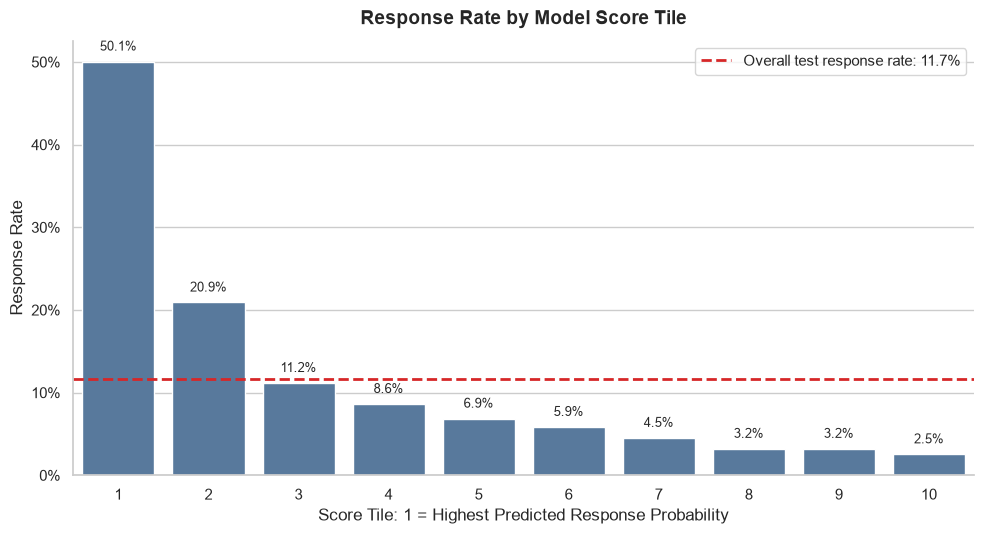

In [240]:
overall_test_response_rate = reduced_rf_predictions['actual_response_flag'].mean()

fig, ax = plt.subplots(figsize=(10, 5.5))
sns.barplot(
    data=reduced_rf_Tile_lift,
    x='score_Tile',
    y='response_rate',
    color='#4C78A8',
    ax=ax
)
ax.axhline(
    overall_test_response_rate,
    color='#D62728',
    linestyle='--',
    linewidth=2,
    label=f'Overall test response rate: {overall_test_response_rate:.1%}'
)
ax.set_title('Response Rate by Model Score Tile', fontsize=14, weight='bold', pad=12)
ax.set_xlabel('Score Tile: 1 = Highest Predicted Response Probability')
ax.set_ylabel('Response Rate')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda value, _: f'{value:.0%}'))
ax.legend(loc='upper right')

for patch, response_rate in zip(ax.patches, reduced_rf_Tile_lift['response_rate']):
    ax.text(
        patch.get_x() + patch.get_width() / 2,
        patch.get_height() + 0.01,
        f'{response_rate:.1%}',
        ha='center',
        va='bottom',
        fontsize=9
    )

sns.despine()
plt.tight_layout()
plt.show()

The highest-scoring tile has a 50.1% response rate versus an 11.7% overall test response rate. This means the top tile responds at more than four times the average rate, confirming that model-based targeting is meaningfully better than random outreach.

### (a) Cumulative Lift Chart

Cumulative lift shows what happens as the business expands the targeting list from the top 10% to the top 20%, 30%, and beyond. This helps identify where the model's advantage starts to flatten.

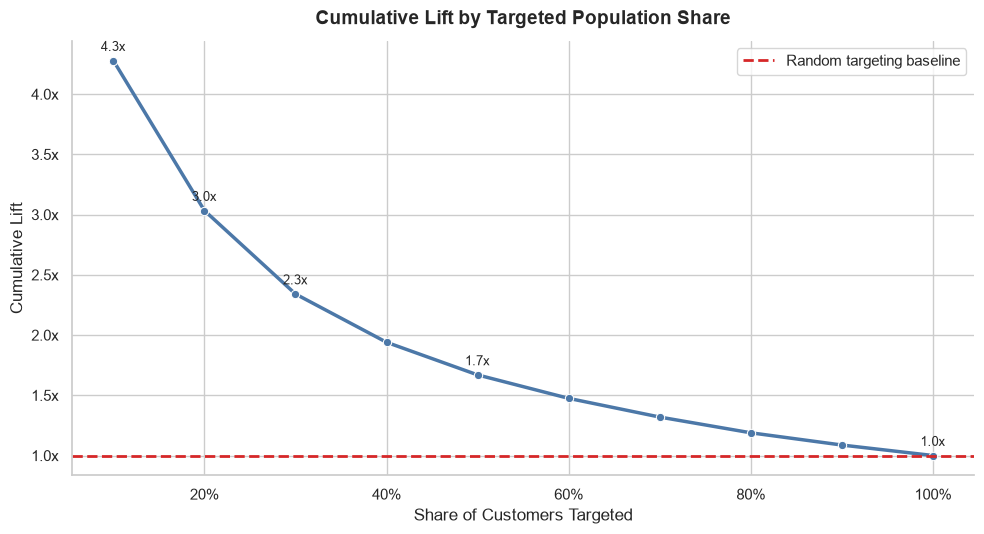

In [241]:
reduced_rf_Tile_lift['targeted_population_pct'] = reduced_rf_Tile_lift['cumulative_customers'] / reduced_rf_Tile_lift['customers'].sum()

fig, ax = plt.subplots(figsize=(10, 5.5))
sns.lineplot(
    data=reduced_rf_Tile_lift,
    x='targeted_population_pct',
    y='cumulative_lift',
    marker='o',
    linewidth=2.5,
    color='#4C78A8',
    ax=ax
)
ax.axhline(1, color='#D62728', linestyle='--', linewidth=2, label='Random targeting baseline')
ax.set_title('Cumulative Lift by Targeted Population Share', fontsize=14, weight='bold', pad=12)
ax.set_xlabel('Share of Customers Targeted')
ax.set_ylabel('Cumulative Lift')
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda value, _: f'{value:.0%}'))
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda value, _: f'{value:.1f}x'))
ax.legend(loc='upper right')

for _, row in reduced_rf_Tile_lift.iterrows():
    if row['score_Tile'] in [1, 2, 3, 5, 10]:
        ax.text(
            row['targeted_population_pct'],
            row['cumulative_lift'] + 0.08,
            f'{row["cumulative_lift"]:.1f}x',
            ha='center',
            fontsize=9
        )

sns.despine()
plt.tight_layout()
plt.show()

Cumulative lift is strongest in the top tiles and steadily declines as lower-scoring customers are added. The model is most valuable when the business targets a smaller, higher-scoring portion of customers rather than everyone.

### (b) Response Capture Curve

The response capture curve shows how many of the total responders are captured as the business targets larger portions of the scored customer list. This is useful because it connects model scores to campaign reach.

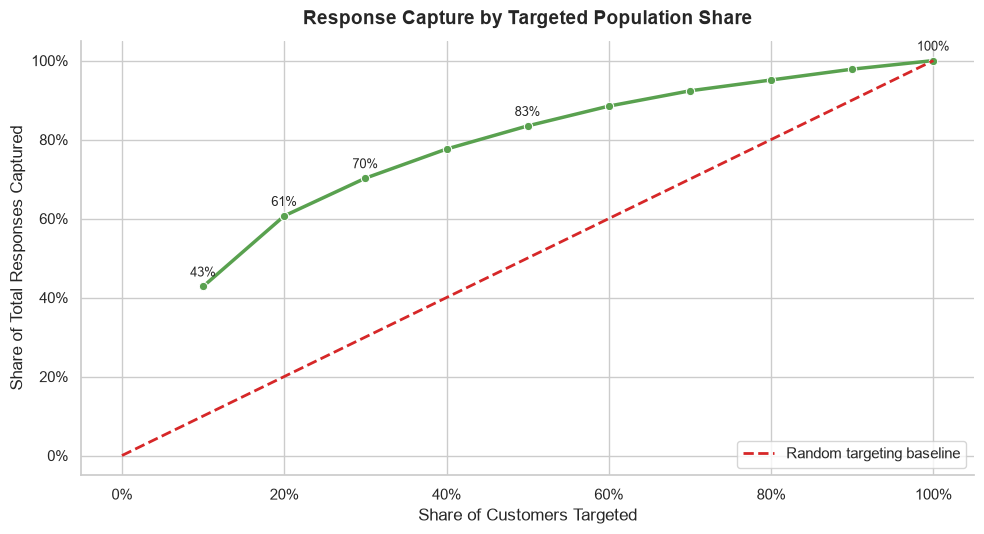

In [242]:
fig, ax = plt.subplots(figsize=(10, 5.5))
sns.lineplot(
    data=reduced_rf_Tile_lift,
    x='targeted_population_pct',
    y='share_of_total_responses_captured',
    marker='o',
    linewidth=2.5,
    color='#59A14F',
    ax=ax
)
ax.plot([0, 1], [0, 1], color='#D62728', linestyle='--', linewidth=2, label='Random targeting baseline')
ax.set_title('Response Capture by Targeted Population Share', fontsize=14, weight='bold', pad=12)
ax.set_xlabel('Share of Customers Targeted')
ax.set_ylabel('Share of Total Responses Captured')
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda value, _: f'{value:.0%}'))
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda value, _: f'{value:.0%}'))
ax.legend(loc='lower right')

for _, row in reduced_rf_Tile_lift.iterrows():
    if row['score_Tile'] in [1, 2, 3, 5, 10]:
        ax.text(
            row['targeted_population_pct'],
            row['share_of_total_responses_captured'] + 0.025,
            f'{row["share_of_total_responses_captured"]:.0%}',
            ha='center',
            fontsize=9
        )

sns.despine()
plt.tight_layout()
plt.show()

The selected model captures about 42.8% of all responders in the top 10% of scored customers and about 60.7% in the top 20%. Random targeting would only be expected to capture about 10% and 20% of responders at those same contact volumes.

### (c) Targeting Threshold Table

The targeting threshold table compares practical campaign options: target only the top 10%, top 20%, top 30%, and so on. This table is the bridge between model output and campaign strategy.

This first targeting view focuses on response lift and response capture. Cost, profit, and ROI are added next.

In [244]:
targeting_thresholds = reduced_rf_Tile_lift.copy()
targeting_thresholds['targeting_strategy'] = 'Top ' + (targeting_thresholds['targeted_population_pct'] * 100).round(0).astype(int).astype(str) + '%'
targeting_thresholds['customers_targeted'] = targeting_thresholds['cumulative_customers']
targeting_thresholds['share_customers_targeted'] = targeting_thresholds['targeted_population_pct']
targeting_thresholds['responses_captured'] = targeting_thresholds['cumulative_responses']
targeting_thresholds['share_responses_captured'] = targeting_thresholds['share_of_total_responses_captured']
targeting_thresholds['targeted_response_rate'] = targeting_thresholds['cumulative_response_rate']
targeting_thresholds['targeted_lift'] = targeting_thresholds['cumulative_lift']

targeting_threshold_table = targeting_thresholds[[
    'targeting_strategy',
    'customers_targeted',
    'share_customers_targeted',
    'responses_captured',
    'share_responses_captured',
    'targeted_response_rate',
    'targeted_lift'
]].copy()

targeting_threshold_table

,targeting_strategy,customers_targeted,share_customers_targeted,responses_captured,share_responses_captured,targeted_response_rate,targeted_lift
9,Top 10%,905,0.1001,453,0.4282,0.5006,4.2784
8,Top 20%,1809,0.2000,642,0.6068,0.3549,3.0334
7,Top 30%,2713,0.3000,743,0.7023,0.2739,2.3408
6,Top 40%,3617,0.4000,821,0.7760,0.2270,1.9401
5,Top 50%,4521,0.4999,883,0.8346,0.1953,1.6694
4,Top 60%,5426,0.6000,936,0.8847,0.1725,1.4744
3,Top 70%,6330,0.7000,977,0.9234,0.1543,1.3192
2,Top 80%,7234,0.8000,1006,0.9509,0.1391,1.1886
1,Top 90%,8138,0.8999,1035,0.9783,0.1272,1.0871
0,Top 100%,9043,1.0000,1058,1.0000,0.1170,1.0000


Targeting the top 10% produces the strongest response rate and lift. Targeting the top 20% captures over 60% of all responders while still maintaining about 3.0x cumulative lift. After the top 30%, lift continues to decline as lower-scoring customers are added.

### (d) Lift and Targeting Conclusions

**Q: What happens if we target only the top 10%?**<br>A: The top 10% targets 905 customers, captures 42.8% of responders, and achieves a 50.1% response rate.

**Q: What happens if we target the top 20%?**<br>A: The top 20% targets 1,809 customers, captures 60.7% of responders, and keeps cumulative lift at 3.0x.

**Q: At what point does lift start to flatten?**<br>A: Lift is strongest in the top 10% and remains attractive through the top 20%; by the top 30%, cumulative lift drops to 2.3x as lower-scoring customers enter the list.

**Q: Is model-based targeting meaningfully better than contacting everyone?**<br>A: Yes. Contacting everyone returns to the baseline 11.7% response rate, while the top 10-20% concentrates a majority of likely responders in a much smaller audience.

## (2) ROI By Targeting Threshold

The lift analysis showed which score groups are most response-efficient. The next step is to translate targeting thresholds into estimated cost, profit, net profit, ROI, and cost per response.

Business assumptions used throughout the project:
- Each customer contact attempt costs **$2**.
- Each successful response creates **$100** in expected profit.

Lift tells us where responses are concentrated. ROI analysis answers the next question: which campaign strategy creates the best business return under the assumptions?

In [249]:
# Add ROI Fields to Targeting Threshold Table

targeting_roi_table = targeting_threshold_table.copy()
targeting_roi_table['estimated_contact_cost'] = targeting_roi_table['customers_targeted'] * CONTACT_COST_PER_ATTEMPT
targeting_roi_table['estimated_gross_profit'] = targeting_roi_table['responses_captured'] * EXPECTED_PROFIT_PER_RESPONSE
targeting_roi_table['estimated_net_profit'] = targeting_roi_table['estimated_gross_profit'] - targeting_roi_table['estimated_contact_cost']
targeting_roi_table['roi'] = targeting_roi_table['estimated_net_profit'] / targeting_roi_table['estimated_contact_cost']
targeting_roi_table['cost_per_response'] = targeting_roi_table['estimated_contact_cost'] / targeting_roi_table['responses_captured']

targeting_roi_table

,targeting_strategy,customers_targeted,share_customers_targeted,responses_captured,share_responses_captured,targeted_response_rate,targeted_lift,estimated_contact_cost,estimated_gross_profit,estimated_net_profit,roi,cost_per_response
9,Top 10%,905,0.1001,453,0.4282,0.5006,4.2784,"1,810.0000","45,300.0000","43,490.0000",24.0276,3.9956
8,Top 20%,1809,0.2000,642,0.6068,0.3549,3.0334,"3,618.0000","64,200.0000","60,582.0000",16.7446,5.6355
7,Top 30%,2713,0.3000,743,0.7023,0.2739,2.3408,"5,426.0000","74,300.0000","68,874.0000",12.6933,7.3028
6,Top 40%,3617,0.4000,821,0.7760,0.2270,1.9401,"7,234.0000","82,100.0000","74,866.0000",10.3492,8.8112
5,Top 50%,4521,0.4999,883,0.8346,0.1953,1.6694,"9,042.0000","88,300.0000","79,258.0000",8.7655,10.2401
4,Top 60%,5426,0.6000,936,0.8847,0.1725,1.4744,"10,852.0000","93,600.0000","82,748.0000",7.6251,11.5940
3,Top 70%,6330,0.7000,977,0.9234,0.1543,1.3192,"12,660.0000","97,700.0000","85,040.0000",6.7172,12.9580
2,Top 80%,7234,0.8000,1006,0.9509,0.1391,1.1886,"14,468.0000","100,600.0000","86,132.0000",5.9533,14.3817
1,Top 90%,8138,0.8999,1035,0.9783,0.1272,1.0871,"16,276.0000","103,500.0000","87,224.0000",5.3591,15.7256
0,Top 100%,9043,1.0000,1058,1.0000,0.1170,1.0000,"18,086.0000","105,800.0000","87,714.0000",4.8498,17.0945


### (a) Compare ROI, Net Profit, and Cost per Response

The next charts show the main tradeoff: narrower targeting is more efficient, while broader targeting may produce more total profit if the marginal groups remain profitable.

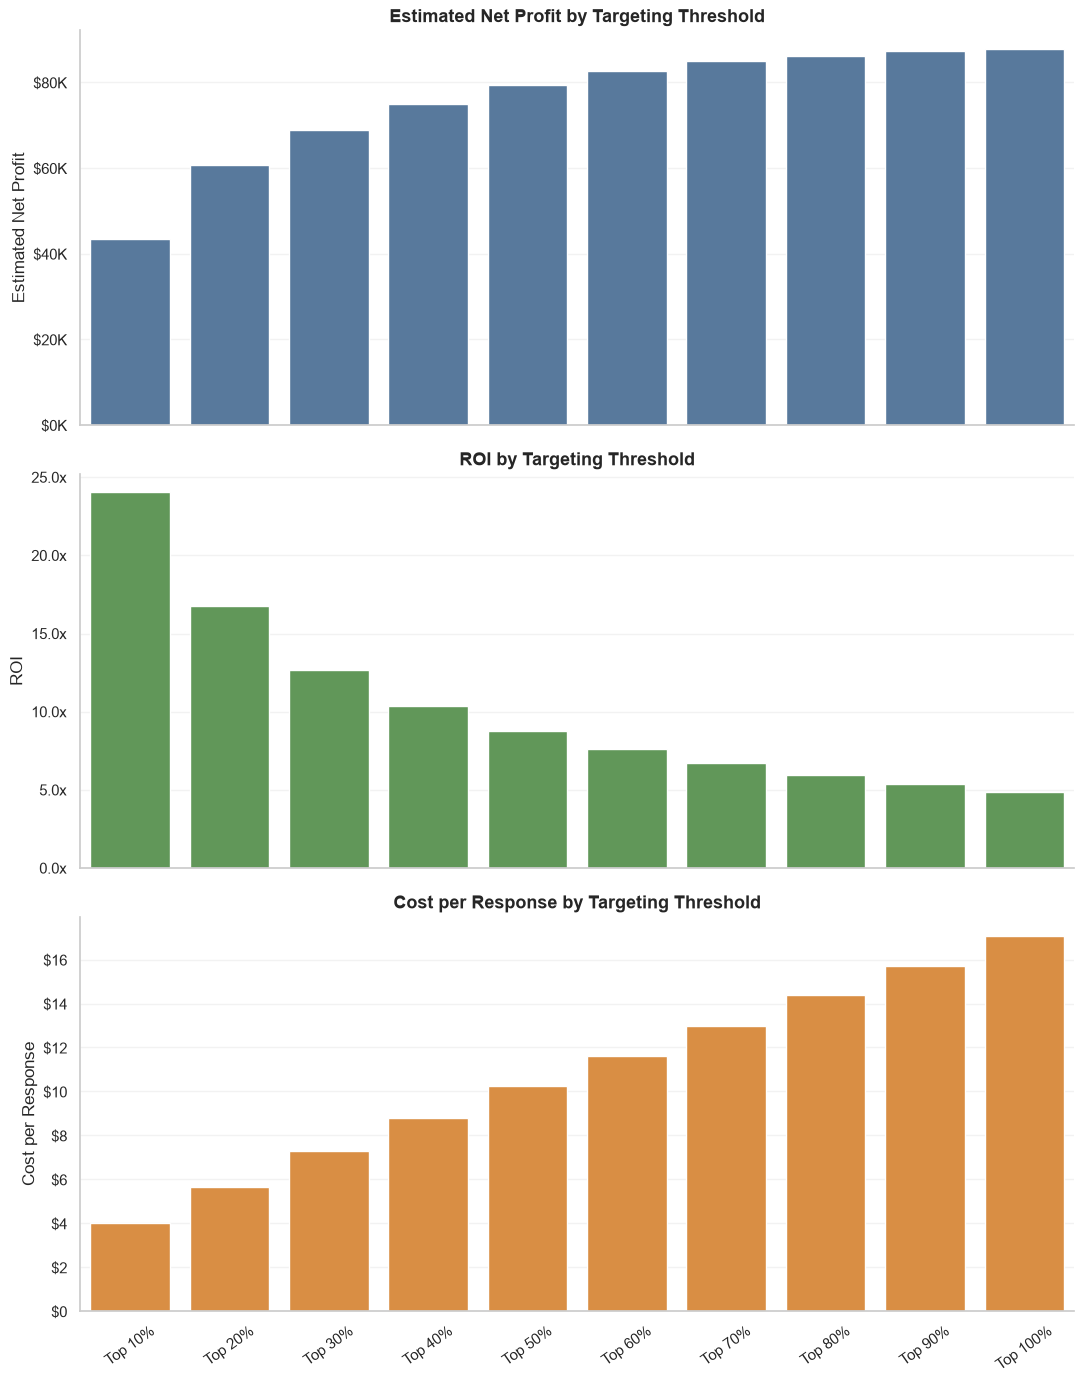

In [251]:
fig, axes = plt.subplots(3, 1, figsize=(11, 14), sharex=True)

sns.barplot(
    data=targeting_roi_table,
    x='targeting_strategy',
    y='estimated_net_profit',
    color='#4C78A8',
    ax=axes[0]
)
axes[0].set_title('Estimated Net Profit by Targeting Threshold', fontsize=13, weight='bold')
axes[0].set_ylabel('Estimated Net Profit')
axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda value, _: f'${value/1000:,.0f}K'))

sns.barplot(
    data=targeting_roi_table,
    x='targeting_strategy',
    y='roi',
    color='#59A14F',
    ax=axes[1]
)
axes[1].set_title('ROI by Targeting Threshold', fontsize=13, weight='bold')
axes[1].set_ylabel('ROI')
axes[1].yaxis.set_major_formatter(plt.FuncFormatter(lambda value, _: f'{value:.1f}x'))

sns.barplot(
    data=targeting_roi_table,
    x='targeting_strategy',
    y='cost_per_response',
    color='#F28E2B',
    ax=axes[2]
)
axes[2].set_title('Cost per Response by Targeting Threshold', fontsize=13, weight='bold')
axes[2].set_ylabel('Cost per Response')
axes[2].set_xlabel('Targeting Threshold')
axes[2].yaxis.set_major_formatter(plt.FuncFormatter(lambda value, _: f'${value:,.0f}'))

for ax in axes:
    ax.set_xlabel('')
    ax.tick_params(axis='x', rotation=35)
    ax.grid(axis='y', alpha=0.25)
    sns.despine(ax=ax)

plt.tight_layout()
plt.show()

ROI and cost per response are best at the top 10% threshold, but estimated net profit continues increasing as more customers are contacted. Under the current assumptions, the model is not only useful for cutting waste; it also shows how efficiency declines as campaign reach expands.

### (b) Marginal ROI by Added Tile

Cumulative thresholds are useful for campaign planning, but marginal tile analysis helps explain whether each additional score group is still worth contacting. If a lower tile has negative marginal profit, the campaign should usually stop before that group.

In [252]:
marginal_Tile_roi = reduced_rf_Tile_lift[[
    'score_Tile',
    'customers',
    'responses',
    'response_rate',
    'lift'
]].copy()
marginal_Tile_roi['estimated_contact_cost'] = marginal_Tile_roi['customers'] * CONTACT_COST_PER_ATTEMPT
marginal_Tile_roi['estimated_gross_profit'] = marginal_Tile_roi['responses'] * EXPECTED_PROFIT_PER_RESPONSE
marginal_Tile_roi['estimated_net_profit'] = marginal_Tile_roi['estimated_gross_profit'] - marginal_Tile_roi['estimated_contact_cost']
marginal_Tile_roi['roi'] = marginal_Tile_roi['estimated_net_profit'] / marginal_Tile_roi['estimated_contact_cost']
marginal_Tile_roi['cost_per_response'] = marginal_Tile_roi['estimated_contact_cost'] / marginal_Tile_roi['responses']

marginal_Tile_roi

,score_Tile,customers,responses,response_rate,lift,estimated_contact_cost,estimated_gross_profit,estimated_net_profit,roi,cost_per_response
9,1,905,453,0.5006,4.2784,"1,810.0000","45,300.0000","43,490.0000",24.0276,3.9956
8,2,904,189,0.2091,1.7870,"1,808.0000","18,900.0000","17,092.0000",9.4535,9.5661
7,3,904,101,0.1117,0.9549,"1,808.0000","10,100.0000","8,292.0000",4.5863,17.9010
6,4,904,78,0.0863,0.7375,"1,808.0000","7,800.0000","5,992.0000",3.3142,23.1795
5,5,904,62,0.0686,0.5862,"1,808.0000","6,200.0000","4,392.0000",2.4292,29.1613
4,6,905,53,0.0586,0.5006,"1,810.0000","5,300.0000","3,490.0000",1.9282,34.1509
3,7,904,41,0.0454,0.3877,"1,808.0000","4,100.0000","2,292.0000",1.2677,44.0976
2,8,904,29,0.0321,0.2742,"1,808.0000","2,900.0000","1,092.0000",0.6040,62.3448
1,9,904,29,0.0321,0.2742,"1,808.0000","2,900.0000","1,092.0000",0.6040,62.3448
0,10,905,23,0.0254,0.2172,"1,810.0000","2,300.0000",490.0000,0.2707,78.6957


Each tile remains profitable under the current assumptions, although marginal ROI declines sharply in lower-score tiles. This explains why contacting all test customers maximizes total net profit, while the top tiles remain far more efficient.

### (c) Business Decision Summary

The best targeting threshold depends on the business objective: budget/capacity control, response efficiency, or total estimated profit.

**Q: Maximize ROI?**<br>A: Top 10%. Top 10% has the highest ROI at 24.0x and the strongest response efficiency.

**Q: Maximize estimated net profit?**<br>A: Top 100%. Top 100% generates the highest estimated net profit at $87,714 because all Tiles remain profitable under the assumptions.

**Q: Minimize cost per response?**<br>A: Top 10%. Top 10% has the lowest cost per response at $4.00.

**Q: Recommended practical targeting range?**<br>A: Top 20% to Top 30%. Top 20% to Top 30% balances scale and efficiency: it captures roughly 61% to 70% of responders while maintaining 3.0x to 2.3x cumulative lift.

# 7. Conclusion

Overall, this project shows that the campaign is profitable at the aggregate level, generating positive estimated net profit and a strong overall ROI. However, the results also show that profitability is not evenly distributed across the customer base. Response rates and ROI vary meaningfully by customer attributes such as age, occupation, balance group, default status, prior campaign outcome, and campaign month, which means a broad contact strategy may waste budget on lower-yield segments while underinvesting in high-value groups. The final business recommendation from this project is to shift from a mass-contact approach to a more targeted campaign strategy. Priority should be given to segments with stronger observed performance, such as customers with prior campaign success, older customers, higher-balance customers, non-default customers, and high-ROI timing windows such as September, October, March, and December. Lower-performing groups should either receive fewer contacts, lower-cost outreach, or be deprioritized unless future testing shows improved returns. This approach should improve campaign efficiency by reducing unnecessary contact costs while preserving, or potentially increasing, total profit.

### Key Takeaways
* **Recommended targeting strategy**: Use the reduced-feature random forest to rank customers and target the top 20% to 30% for the next campaign.

* **Efficiency option**: If the business has strict capacity or budget limits, target the top 10%; this maximizes ROI and minimizes cost per response.

* **Scale option**: If the business wants more reach while preserving strong lift, target the top 20% to 30%; this captures roughly 61% to 70% of responders.

* **Target first**: Prioritize high model scores, prior campaign success, cellular contact, favorable campaign months, stronger balance profiles, no personal loan, no housing loan, and customer groups that showed strong response patterns such as students, retirees, and older customers.

* **Deprioritize or review carefully**: Review low model scores, 6+ contact attempts, unknown contact channel, negative balance, personal loan burden, both housing and personal loans, and default status before including them in a broad campaign.

* **Expected impact**: Top 20% targets 1,809 customers, captures 60.7% of responders, has a 35.5% response rate, 3.0x lift, 16.7x ROI, and $60,582 estimated net profit. Top 30% captures 70.2% of responders, has a 27.4% response rate, 2.3x lift, 12.7x ROI, and $68,874 estimated net profit.

* **Key assumptions**: ROI estimates assume $2 per contact attempt and $100 expected profit per successful response. These are synthetic assumptions for scenario analysis, not actual bank financials.

* **Risks and caveats**: The dataset is historical and public, does not include true customer IDs or complete campaign dates, and should be validated on a future campaign. Duration was excluded to prevent target leakage. The model also uses planned contact/timing fields, so those fields must be known before scoring; otherwise a stricter customer-only model should be rebuilt.

* **Future steps**: Validate the model on new campaign data, replace synthetic assumptions with actual cost/profit values, run a controlled targeting test, monitor response and customer fatigue, and retrain the model periodically.

### Review of Assumptions and Risks

1. The analysis accounts for potential target leakage by excluding `duration`, response labels, and response-derived profit fields before modeling. This is important because those variables would not be known before making a targeting decision. However, contact and timing fields should only be used if they are known or planned before the customer is scored.

2. The model is framed as an operational campaign-targeting model rather than a pure customer-only prospecting model. This means it is most appropriate when campaign rules, such as contact strategy or timing, are already defined. If the business needs to score customers before deciding contact channel, month, or outreach plan, then the model should be rebuilt using only customer-level information available before campaign planning.

3. Model performance should be evaluated using metrics that match a rare-response campaign. Accuracy alone is not sufficient because response events are relatively uncommon. More relevant metrics include PR AUC, tile lift, response capture, cost per response, estimated net profit, and ROI. Future validation should compare the modeled targeting strategy against a randomized holdout group or an existing champion strategy.

4. The ROI recommendation depends on assumed economics, including a $2 contact cost and $100 profit per response. These assumptions make the business impact easier to estimate, but actual campaign costs, product margins, customer lifetime value, and operational capacity constraints could change the best targeting threshold.

5. Model interpretation should be handled carefully. Feature importance and segment-level differences are useful for understanding model behavior and guiding business review, but they should not be treated as causal evidence. A production rollout should also monitor customer experience risks, including repeated contacts, opt-outs, complaints, and channel-level response quality, to ensure that more precise targeting does not create contact fatigue or reduce customer trust.